In [52]:
import pandas as pd
import pickle
import dask.dataframe as dd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
genes = ['2_199', '3_2730', '5_2244']

In [3]:
dict_blocks = '../key_files/blocks_snpsid_dict.pkl'

with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

In [4]:
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')

In [7]:
snps_dict['block'] = snps_dict['id'].map(reverse_mapping)

In [8]:
snps_dict_filt = snps_dict[snps_dict['block'].isin(genes)]

In [9]:
for i in genes:
    print(snps_dict[snps_dict['block'].isin([i])].index.values[0] + 2)
    print(snps_dict[snps_dict['block'].isin([i])].index.values[-1] + 2)

845212
845232
1868509
1868608
3053517
3053587


In [21]:
snps_dict[snps_dict['maf05filter'].notna()]

,id,pos,chrom,maf05filter,total_alleles05filter,block
1,1_346,346,1,1_346,1_346,1_0
4,1_353,353,1,1_353,NaN,1_0
5,1_363,363,1,1_363,NaN,1_0
6,1_395,395,1,1_395,NaN,1_0
7,1_396,396,1,1_396,NaN,1_0
...,...,...,...,...,...,...
3235468,5_26975078,26975078,5,5_26975078,5_26975078,5_3110
3235470,5_26975121,26975121,5,5_26975121,NaN,5_3110
3235472,5_26975148,26975148,5,5_26975148,NaN,5_3110
3235478,5_26975272,26975272,5,5_26975272,5_26975272,5_3110


In [ ]:
snps_dict[snps_dict[]]

In [ ]:
for i in genes:
    print(snps_dict[snps_dict['block'].isin([i])].index.values[0] + 2)
    print(snps_dict[snps_dict['block'].isin([i])].index.values[-1] + 2)

In [ ]:
awk 'NR >= 845212 && NR <= 845232' ../key_files/merged_hapFIRE_allele_frequency.txt > filtered_blocks.csv

In [ ]:
'../key_files/merged_hapFIRE_delta_p.txt'

In [ ]:
'../key_files/allele_counts_first_gen_filtermaf05.csv'

In [ ]:
awk 'NR >= 845212 && NR <= 845232 || NR >= 1868509 && NR <= 1868608 || NR >= 3053517 && NR <= 3053587' ../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv > filtered_blocks.csv

In [ ]:
awk 'NR >= 845212 && NR <= 845232 || NR >= 1868509 && NR <= 1868608 || NR >= 3053517 && NR <= 3053587' ../key_files/merged_hapFIRE_delta_p.txt > filtered_blocks_deltap.csv

In [ ]:
## allele counts

af = pd.read_csv('filtered_blocks.csv',header=None)
usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af.columns = usecols

flowers = pd.read_csv('../key_files/merged_sample_table.csv')

#path_meixi = '/carnegie/data/Shared/Labs/Moi/Everyone/meixilin'

num_flowers_map = flowers.set_index('sample_name')['total_flower_counts'].to_dict()

allele_counts = {}
for i in af.columns:
    num_flowers = num_flowers_map[i]
    allele_counts[i] =af[i] * (num_flowers*2)

allele_counts = pd.concat(allele_counts,axis=1)

In [42]:
snps_dict_filt = snps_dict_filt.reset_index(drop=True)

In [43]:
causal = pd.concat([allele_counts, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

In [44]:
causal

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_606065,84.860414,140.096628,121.420890,121.608636,132.106036,109.249000,116.703338,74.731530,126.200944,127.433270,...,4.12916,11.12338,10.757488,4.159992,12.063934,11.124780,3.398114,4.263028,4.49518,9.29922
2_606118,90.256724,148.440342,124.278620,127.110914,134.645726,112.150114,121.095812,85.116198,132.803818,121.923390,...,4.09580,4.25348,10.787068,4.178096,12.099942,11.133414,3.398418,5.566974,4.52029,12.12784
2_606124,90.256724,148.440342,124.278620,127.110914,134.645726,112.150114,121.095812,85.116198,132.803818,121.923390,...,4.09580,4.25348,10.787068,4.178096,12.099942,11.133414,3.398418,5.566974,4.52029,12.12784
2_606166,90.256724,148.440342,124.278620,127.110914,134.645726,112.150114,121.095812,85.116198,132.803818,121.923390,...,4.09580,4.25348,10.787068,4.178096,12.099942,11.133414,3.398418,5.566974,4.52029,12.12784
2_606190,87.876052,138.494160,122.200860,121.723384,133.876392,105.126150,118.982314,75.047230,128.148106,117.308426,...,4.06122,4.23472,10.768266,4.167432,12.088044,11.035416,3.392208,5.538666,4.50997,12.07776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5_19685291,119.620396,231.371046,241.618668,256.422446,258.917004,199.684654,265.700314,178.907592,255.126790,297.931864,...,23.62440,30.64904,24.883360,27.424456,11.578394,22.874148,10.425948,36.557822,26.36750,28.66358
5_19685375,180.586172,268.181334,293.207544,283.331022,270.043486,188.920756,309.148954,190.015870,275.846342,305.551068,...,25.69674,9.49090,25.030070,24.064672,11.873148,29.024274,10.562512,35.698376,19.75900,33.58632
5_19685384,27.336430,49.748866,60.400144,62.826318,47.470938,60.462454,69.088890,41.485534,53.008324,70.525030,...,4.57282,19.99816,3.100464,5.270552,3.438080,1.807248,6.546690,2.752302,7.34197,1.88792


In [31]:
af = af.drop(['Unnamed: 745','0'],axis=1)

In [10]:
usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 

In [11]:
usecols = usecols[:-2]

In [12]:
#usecols = pd.read_csv('../key_files/merged_hapFIRE_delta_p.txt',nrows =1,sep = '\t').columns 

In [13]:
af_filt_blocks = pd.read_csv('filtered_blocks_deltap.csv', sep = '\t',header=None)

In [14]:
af_filt_blocks.columns = usecols

In [15]:
snps_dict_filt = snps_dict_filt.reset_index(drop=True)

In [17]:
causal = pd.concat([af_filt_blocks, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

In [209]:
#af_filt_blocks = af_filt_blocks.drop('Unnamed: 745',axis=1)

In [19]:
causal

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_606065,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
2_606118,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
2_606124,0.031364,0.006667,0.012723,-0.010902,0.009477,0.024194,-0.010332,-0.002039,0.012303,0.025621,...,-0.015498,0.313520,-0.027005,-0.028331,-0.014963,-0.023843,-0.023846,-0.009218,-0.028349,-0.024980
2_606166,-0.057629,-0.063906,-0.091760,-0.097366,-0.062388,-0.099643,-0.124357,-0.110074,-0.060556,-0.135555,...,-0.257044,-0.252707,-0.041861,-0.228342,0.190882,-0.128670,-0.116274,-0.226702,-0.245825,-0.056631
2_606190,-0.053716,-0.046983,-0.091463,-0.090044,-0.064925,-0.086582,-0.124436,-0.080972,-0.053968,-0.131020,...,-0.260419,-0.256477,-0.045547,-0.232248,0.187183,-0.130868,-0.120070,-0.230267,-0.249807,-0.059618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5_19685291,-0.023648,-0.015333,-0.027204,-0.009965,-0.028725,0.011284,-0.027460,-0.020514,-0.030474,0.011657,...,-0.045801,0.426635,-0.060026,-0.016837,0.080039,-0.044176,-0.048305,-0.047620,-0.058375,-0.054268
5_19685375,-0.027750,-0.015519,0.010510,0.013452,-0.016344,0.027554,0.014634,0.016001,0.001907,0.012710,...,-0.007048,0.378586,-0.030178,0.043337,0.034908,-0.083717,0.346253,-0.055837,0.062181,-0.074170
5_19685384,-0.117077,-0.035809,-0.008876,0.016223,0.034097,-0.033899,-0.004072,0.067427,0.054777,0.038217,...,0.067504,0.244475,0.210742,0.316421,0.004216,-0.047872,0.221585,0.306534,0.137721,0.194178


In [45]:
first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

In [47]:
causal_first_gen = causal[first_gen]

In [48]:
samples = causal_first_gen.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [ ]:
causal_values = causal_first_gen.reset_index().drop(columns='id').T

In [49]:
bio1

0      10.209418
1      10.209418
2      10.209418
3      10.209418
4      10.209418
         ...    
321    18.908464
322    18.908464
323    18.908464
324    18.908464
325    18.908464
Name: bio1, Length: 326, dtype: float64

In [54]:
bio1

0      10.209418
1      10.209418
2      10.209418
3      10.209418
4      10.209418
         ...    
321    18.908464
322    18.908464
323    18.908464
324    18.908464
325    18.908464
Name: bio1, Length: 326, dtype: float64

In [55]:
causal_values

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
1_1_1,84.860414,90.256724,90.256724,90.256724,87.876052,90.256724,90.256724,90.256724,90.256724,186.060364,...,31.514780,61.640722,61.807984,118.677968,104.991004,119.620396,180.586172,27.336430,117.794928,27.033098
1_1_2,140.096628,148.440342,148.440342,148.440342,138.494160,148.440342,148.440342,148.440342,148.440342,309.650644,...,36.706078,86.127956,88.719118,226.834430,199.665072,231.371046,268.181334,49.748866,227.797316,34.406994
1_1_3,121.420890,124.278620,124.278620,124.278620,122.200860,124.278620,124.278620,124.278620,124.278620,295.851394,...,44.715170,126.438948,126.696148,238.731446,214.238642,241.618668,293.207544,60.400144,234.316654,42.530192
1_1_4,121.608636,127.110914,127.110914,127.110914,121.723384,127.110914,127.110914,127.110914,127.110914,276.200494,...,56.018382,125.899614,126.779614,254.394172,216.668144,256.422446,283.331022,62.826318,250.105286,48.890750
1_1_5,132.106036,134.645726,134.645726,134.645726,133.876392,134.645726,134.645726,134.645726,134.645726,275.176526,...,59.194984,115.540372,116.155402,252.393996,231.153006,258.917004,270.043486,47.470938,250.670678,57.109876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60_1_8,11.124780,11.133414,11.133414,11.133414,11.035416,11.133414,11.133414,11.133414,11.133414,28.143630,...,7.530804,12.310590,12.432372,22.800174,20.525352,22.874148,29.024274,1.807248,22.685394,7.410090
60_1_9,3.398114,3.398418,3.398418,3.398418,3.392208,3.398418,3.398418,3.398418,3.398418,3.741678,...,0.226966,6.734398,6.998008,10.352578,10.133752,10.425948,10.562512,6.546690,10.388972,0.218036
60_1_10,4.263028,5.566974,5.566974,5.566974,5.538666,5.566974,5.566974,5.566974,5.566974,22.185814,...,18.255524,21.943138,22.005704,36.513568,35.696374,36.557822,35.698376,2.752302,34.734756,18.224738
60_1_11,4.495180,4.520290,4.520290,4.520290,4.509970,4.520290,4.520290,4.520290,4.520290,15.590040,...,6.580410,13.857510,13.956510,26.321510,19.474690,26.367500,19.759000,7.341970,26.328200,6.571890


In [74]:
colors = sns.color_palette("viridis", n_colors = 3)

# Create a dictionary that maps each block to a specific color
block_color_dict = {
    '2_199': colors[0],
    '3_2730': colors[1],
    '5_2244': colors[2]
}

In [60]:
block_rows

Index([ 31,  34,  39,  42,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  66,  67,  68,  70,  71,  72,  73,  74,  75,  77,  78,
        80,  81,  83,  84,  87,  88,  90,  92,  94,  95, 100, 102, 103, 104,
       105, 107, 113],
      dtype='int64')

In [64]:
causal_det = causal_det.reset_index(drop=True)

In [65]:
 causal_det['block'].unique()

array(['2_199', '3_2730', '5_2244'], dtype=object)

In [70]:
bio1.index = causal_values.index

,0,1,2,3,4,5,6,7,8,9,...,68,69,70,71,72,73,74,75,76,77
1_1_1,84.860414,90.256724,90.256724,90.256724,87.876052,90.256724,90.256724,90.256724,90.256724,186.060364,...,31.514780,61.640722,61.807984,118.677968,104.991004,119.620396,180.586172,27.336430,117.794928,27.033098
1_1_2,140.096628,148.440342,148.440342,148.440342,138.494160,148.440342,148.440342,148.440342,148.440342,309.650644,...,36.706078,86.127956,88.719118,226.834430,199.665072,231.371046,268.181334,49.748866,227.797316,34.406994
1_1_3,121.420890,124.278620,124.278620,124.278620,122.200860,124.278620,124.278620,124.278620,124.278620,295.851394,...,44.715170,126.438948,126.696148,238.731446,214.238642,241.618668,293.207544,60.400144,234.316654,42.530192
1_1_4,121.608636,127.110914,127.110914,127.110914,121.723384,127.110914,127.110914,127.110914,127.110914,276.200494,...,56.018382,125.899614,126.779614,254.394172,216.668144,256.422446,283.331022,62.826318,250.105286,48.890750
1_1_5,132.106036,134.645726,134.645726,134.645726,133.876392,134.645726,134.645726,134.645726,134.645726,275.176526,...,59.194984,115.540372,116.155402,252.393996,231.153006,258.917004,270.043486,47.470938,250.670678,57.109876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60_1_8,11.124780,11.133414,11.133414,11.133414,11.035416,11.133414,11.133414,11.133414,11.133414,28.143630,...,7.530804,12.310590,12.432372,22.800174,20.525352,22.874148,29.024274,1.807248,22.685394,7.410090
60_1_9,3.398114,3.398418,3.398418,3.398418,3.392208,3.398418,3.398418,3.398418,3.398418,3.741678,...,0.226966,6.734398,6.998008,10.352578,10.133752,10.425948,10.562512,6.546690,10.388972,0.218036
60_1_10,4.263028,5.566974,5.566974,5.566974,5.538666,5.566974,5.566974,5.566974,5.566974,22.185814,...,18.255524,21.943138,22.005704,36.513568,35.696374,36.557822,35.698376,2.752302,34.734756,18.224738
60_1_11,4.495180,4.520290,4.520290,4.520290,4.509970,4.520290,4.520290,4.520290,4.520290,15.590040,...,6.580410,13.857510,13.956510,26.321510,19.474690,26.367500,19.759000,7.341970,26.328200,6.571890


In [68]:
causal_values[row]

1_1_1      27.033098
1_1_2      34.406994
1_1_3      42.530192
1_1_4      48.890750
1_1_5      57.109876
             ...    
60_1_8      7.410090
60_1_9      0.218036
60_1_10    18.224738
60_1_11     6.571890
60_1_12     4.971220
Name: 77, Length: 326, dtype: float64

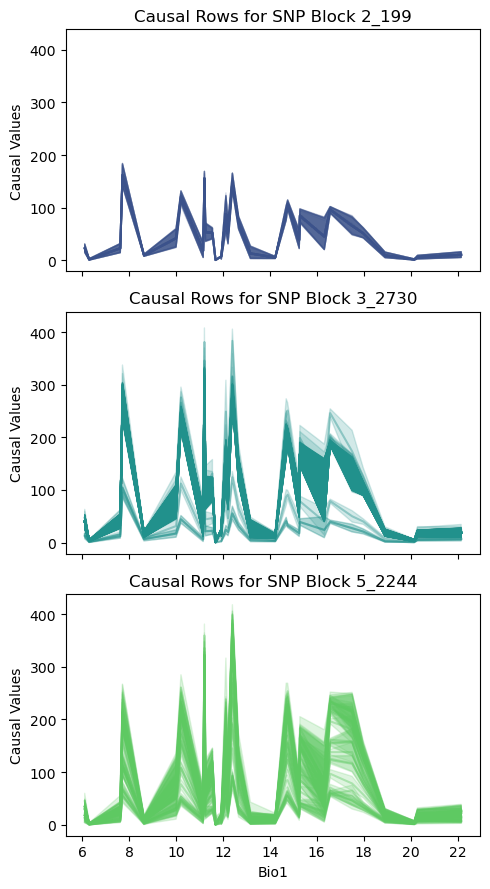

In [80]:
from scipy.stats import linregress


r2 = []
# Identify unique blocks from your data
unique_blocks = causal_det['block'].unique()

# Create subplots: one for each unique block
# Create subplots: one for each unique block
fig, axes = plt.subplots(nrows=len(unique_blocks), figsize=(5, 3 * len(unique_blocks)), sharex=True,sharey=True)
# If there's only one unique block, `axes` will not be an array, so we make it one
if len(unique_blocks) == 1:
    axes = [axes]

# Plot each row of causal as a line in the corresponding subplot
for i, block in enumerate(unique_blocks):
    # Filter the rows corresponding to the current block
    block_rows = causal_det[causal_det['block'] == block].index
    color = block_color_dict[block]
    
    for row in block_rows:
        # Perform linear regression between bio1 and the current row of causal values
        slope, intercept, r_value, p_value, std_err = linregress(bio1, causal_values[row])
        
        # Plot the causal values for this row
        sns.lineplot(x=bio1, y=causal_values[row], ax=axes[i], label=f'Row {row + 1}', color=color, alpha=0.4, legend=False)
        
        # Annotate the plot with the R-squared value
        r2.append(r_value)
    
    # Set labels and title for each subplot
    axes[i].set_title(f'Causal Rows for SNP Block {block}')
    axes[i].set_xlabel('Bio1')
    axes[i].set_ylabel('Causal Values')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


In [82]:
snps = '5_19684756'
pos = 19684756

In [89]:
af = pd.read_csv('filtered_blocks.csv',header=None)
usecols = pd.read_csv('../baypass_terminal/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af.columns = usecols

flowers = pd.read_csv('../key_files/merged_sample_table.csv')

#path_meixi = '/carnegie/data/Shared/Labs/Moi/Everyone/meixilin'

num_flowers_map = flowers.set_index('sample_name')['total_flower_counts'].to_dict()

allele_counts = {}
for i in af.columns[:-2]:
    num_flowers = num_flowers_map[i]
    allele_counts[i] =af[i] * (num_flowers*2)

allele_counts = pd.concat(allele_counts,axis=1)

In [92]:

snps_dict_filt = snps_dict_filt.reset_index(drop=True)

causal = pd.concat([allele_counts, snps_dict_filt],axis=1)

causal = causal[causal['total_alleles05filter'].notna()]

causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block']].copy()

causal =causal.drop(['pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

causal_det = causal_det.reset_index(drop=True)

mask = causal_det['pos'] == pos

causal = causal.reset_index(drop=True)

pos2_606065 = causal[mask]

In [94]:
samples = pos2_606065.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

pos2_606065 = pos2_606065.T.reset_index()

pos2_606065.columns = ['sample', 'af']

pos2_606065 = pd.concat([pos2_606065, env[['site', 'bio1']]],axis=1)

pos2_606065['gen'] = pos2_606065['sample'].str.split('_').str[1]
pos2_606065['plot'] = pos2_606065['sample'].str.split('_').str[2]

pos2_606065['site_plot'] = pos2_606065['site'].astype(str) + '_' + pos2_606065['plot'].astype(str)

pos2_pivot= pos2_606065.pivot_table(index = ['site_plot'], columns = 'gen', values = 'af')

In [95]:
p0_average_seed_mix = pd.read_csv('../key_files/p0_average_seed_mix.csv')
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')
p0_average_seed_mix = pd.concat([p0_average_seed_mix,snps_dict ], axis=1)
initial_freq = p0_average_seed_mix[p0_average_seed_mix['id'] == snps]['0'].values[0]

In [96]:
initial_freq

0.545787

In [97]:
samples_env = pos2_606065[['site_plot', 'bio1']]
samples_env = samples_env.drop_duplicates()
# First, ensure that the 'sample' is reset as a column in pos2_pivot for merging
pos2_pivot_reset = pos2_pivot.reset_index()

# Merge pos2_pivot with samples_env based on the 'sample' column
merged_df = pos2_pivot_reset.merge(samples_env, on='site_plot')
merged_df = merged_df.dropna(thresh=2, subset=['1', '2', '3'])

In [98]:
merged_df['bio1_group'] = pd.cut(merged_df['bio1'], bins=10)
bio1_groups = merged_df.groupby('bio1_group')


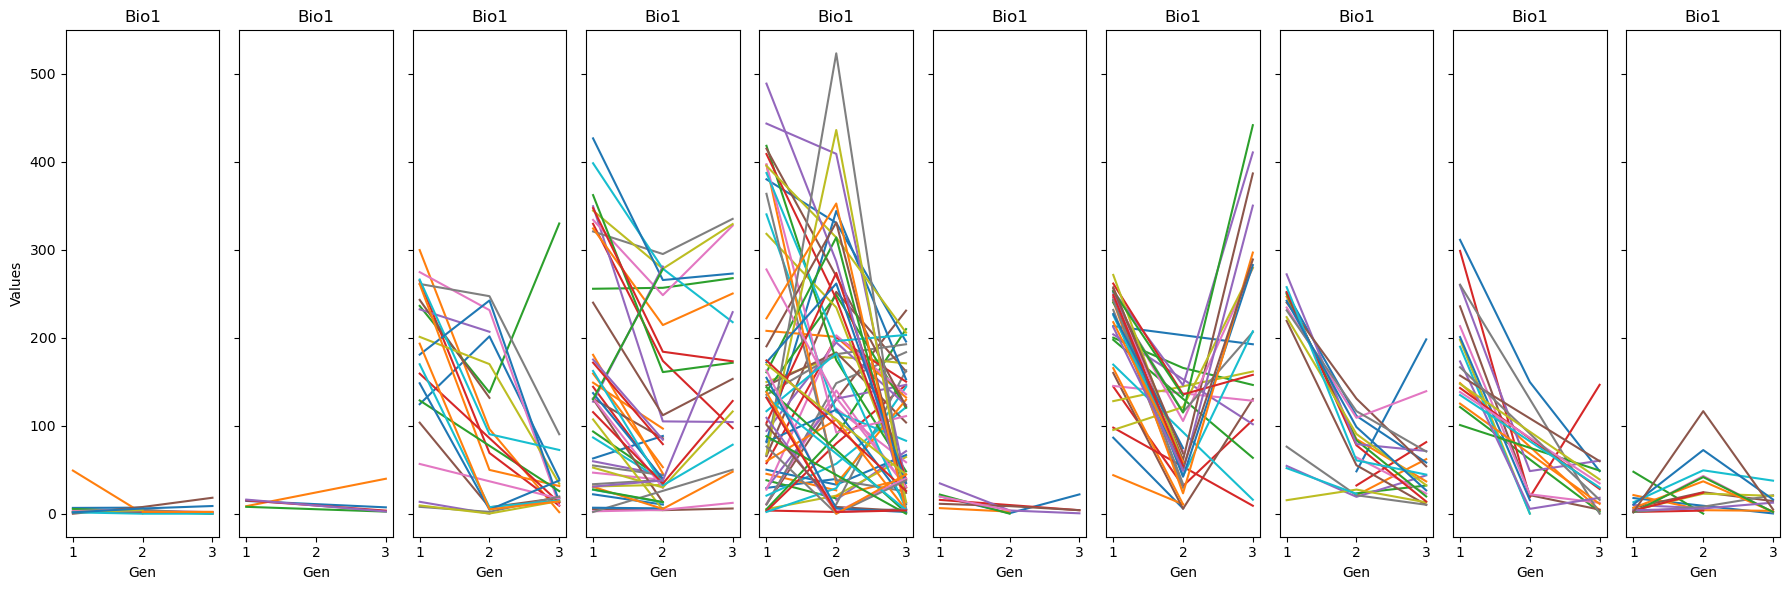

In [101]:
import math

# Set the number of columns for the plot grid
n_cols = len(bio1_groups)  # You can adjust this number based on your needs
n_rows = math.ceil(len(bio1_groups) / n_cols)

# Create subplots with multiple columns
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 6 * n_rows), sharex=True, sharey=True)

# Flatten axes if we have multiple rows/columns
axes = axes.flatten()

# Plot each group of samples in a different subplot
for i, (bio1, group) in enumerate(bio1_groups):
    # Plot each row (sample) in the group
    for _, row in group.iterrows():
        sns.lineplot(x=[1, 2, 3], y=row[['1', '2', '3']], ax=axes[i], label=row['site_plot'], legend=False)
    
    # Set the title and labels for each subplot
    axes[i].set_title(f'Bio1')
    axes[i].set_xlabel('Gen')
    axes[i].set_ylabel('Values')

# Remove unused subplots if there are any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [118]:
## cehcking that the awk filtering is working 
#(snps_dict_filt['id'].values == af_filt_blocks['0'].values).all()

True

In [18]:
first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

In [247]:
causal_first_gen = causal[first_gen]

In [240]:
causal_loci_save = causal.index

In [248]:
causal_values = causal_first_gen.reset_index().drop(columns='id').T

In [278]:
causal_values = pd.concat([causal_values,bio1],axis=1)

In [286]:
causal_values = causal_values.groupby('bio1')[[     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,     10,     11,     12,     13,     14,     15,     16,     17,
           18,     19,     20,     21,     22,     23,     24,     25,     26,
           27,     28,     29,     30,     31,     32,     33,     34,     35,
           36,     37,     38,     39,     40,     41,     42,     43,     44,
           45,     46,     47,     48,     49,     50,     51,     52,     53,
           54,     55,     56,     57,     58,     59,     60,     61,     62,
           63,     64,     65,     66,     67,     68,     69,     70,     71,
           72,     73,     74,     75,     76,     77,]].mean()

In [295]:
causal_values = causal_values.reset_index(drop=True)

In [296]:
causal_values.shape

(31, 78)

In [251]:
samples = causal_first_gen.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [292]:
bio1 =bio1.reset_index(drop=True).drop_duplicates().reset_index(drop=True)

In [252]:
bio1.index = causal_values.index

In [253]:
causal_values.shape[1]

78

In [254]:
causal_values[1]

1_1_1     -0.053716
1_1_2     -0.046983
1_1_3     -0.091463
1_1_4     -0.090044
1_1_5     -0.064925
             ...   
60_1_8    -0.130868
60_1_9    -0.120070
60_1_10   -0.230267
60_1_11   -0.249807
60_1_12   -0.059618
Name: 1, Length: 326, dtype: float64

In [257]:
causal_values[i]

1_1_1     -0.008183
1_1_2     -0.012412
1_1_3      0.005365
1_1_4     -0.013998
1_1_5     -0.013806
             ...   
60_1_8    -0.028385
60_1_9    -0.023339
60_1_10    0.165001
60_1_11   -0.006004
60_1_12   -0.032682
Name: 9, Length: 326, dtype: float64

In [261]:
causal_det = causal_det.reset_index(drop=True)

In [266]:
# Create a dictionary that maps each block to a specific color
block_color_dict = {
    '2_199': 'blue',
    '3_2730': 'green',
    '5_2244': 'red'
}

In [267]:
snp_block = causal_det.loc[i,'block']

'green'

In [269]:
snp_block[block_color_dict]

TypeError: string indices must be integers

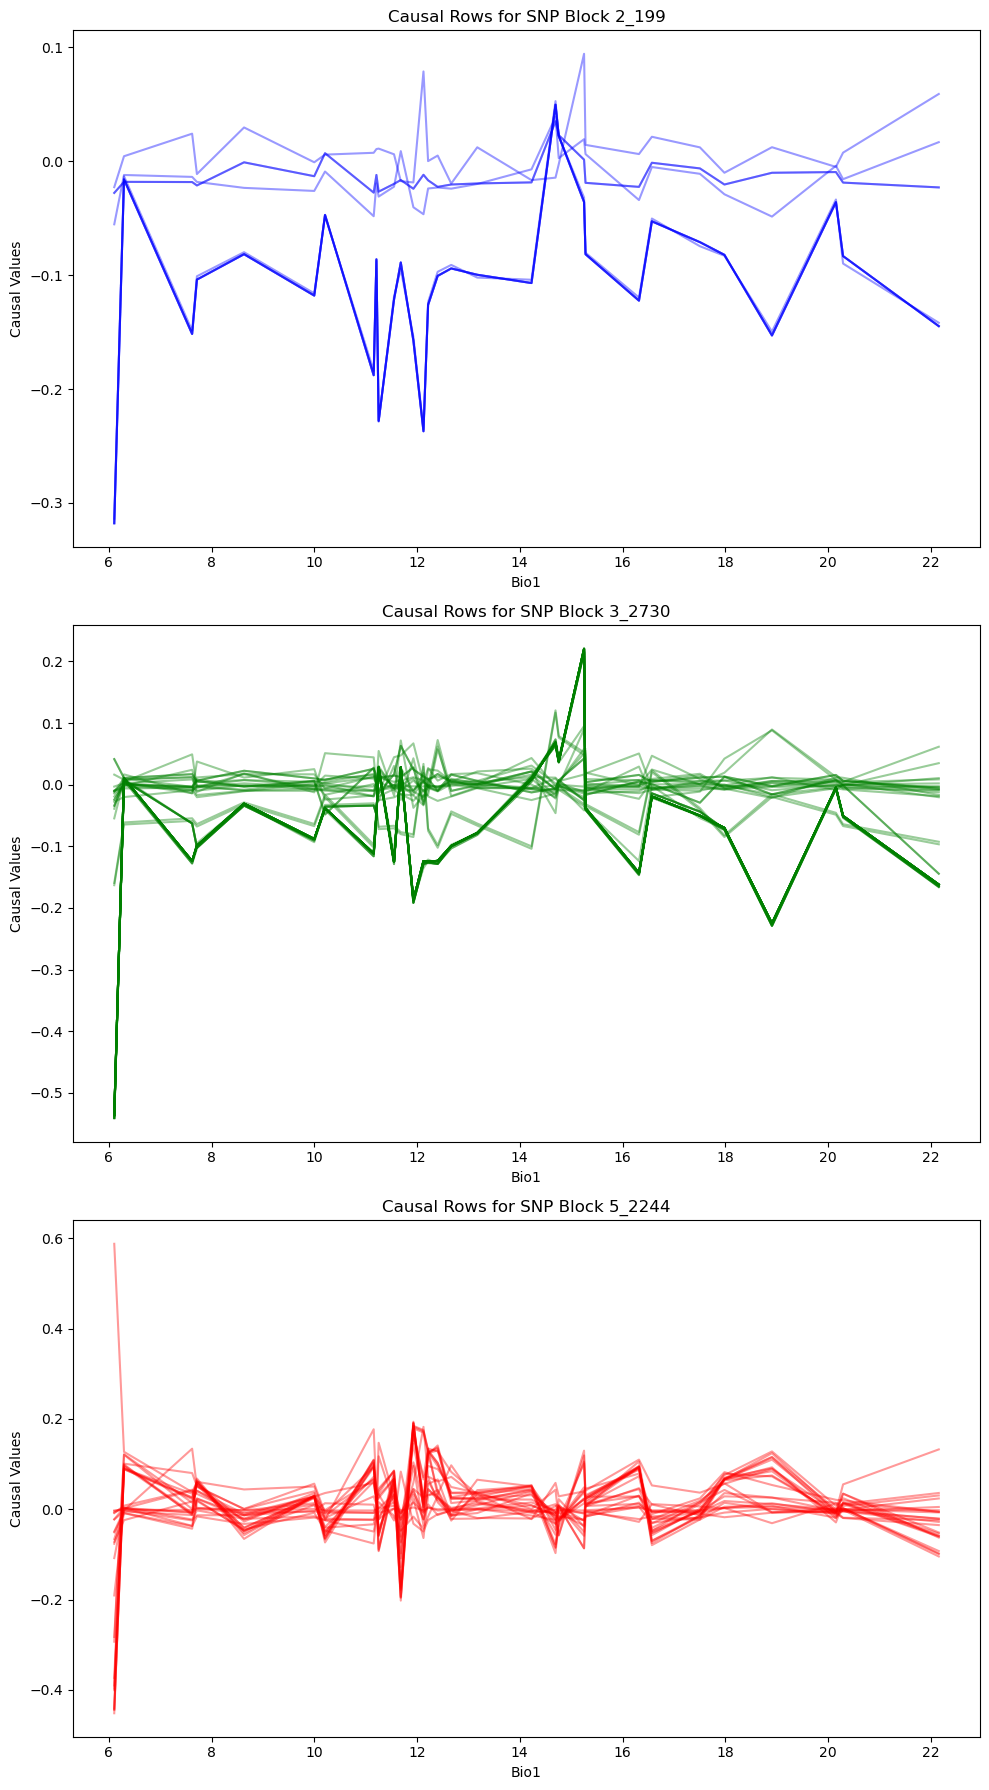

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify unique blocks from your data
unique_blocks = causal_det['block'].unique()

# Create subplots: one for each unique block
fig, axes = plt.subplots(nrows=len(unique_blocks), figsize=(10, 6 * len(unique_blocks)))

# If there's only one unique block, `axes` will not be an array, so we make it one
if len(unique_blocks) == 1:
    axes = [axes]

# Plot each row of causal as a line in the corresponding subplot
for i, block in enumerate(unique_blocks):
    # Filter the rows corresponding to the current block
    block_rows = causal_det[causal_det['block'] == block].index
    color = block_color_dict[block]
    
    for row in block_rows:
        sns.lineplot(x=bio1, y=causal_values[row], ax=axes[i], label=f'Row {row + 1}', color=color, alpha=0.4, legend=False)
    
    # Set labels and title for each subplot
    axes[i].set_title(f'Causal Rows for SNP Block {block}')
    axes[i].set_xlabel('Bio1')
    axes[i].set_ylabel('Causal Values')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()


In [259]:
causal_values.shape[1]

78

/tmp/ipykernel_3504670/1189033000.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


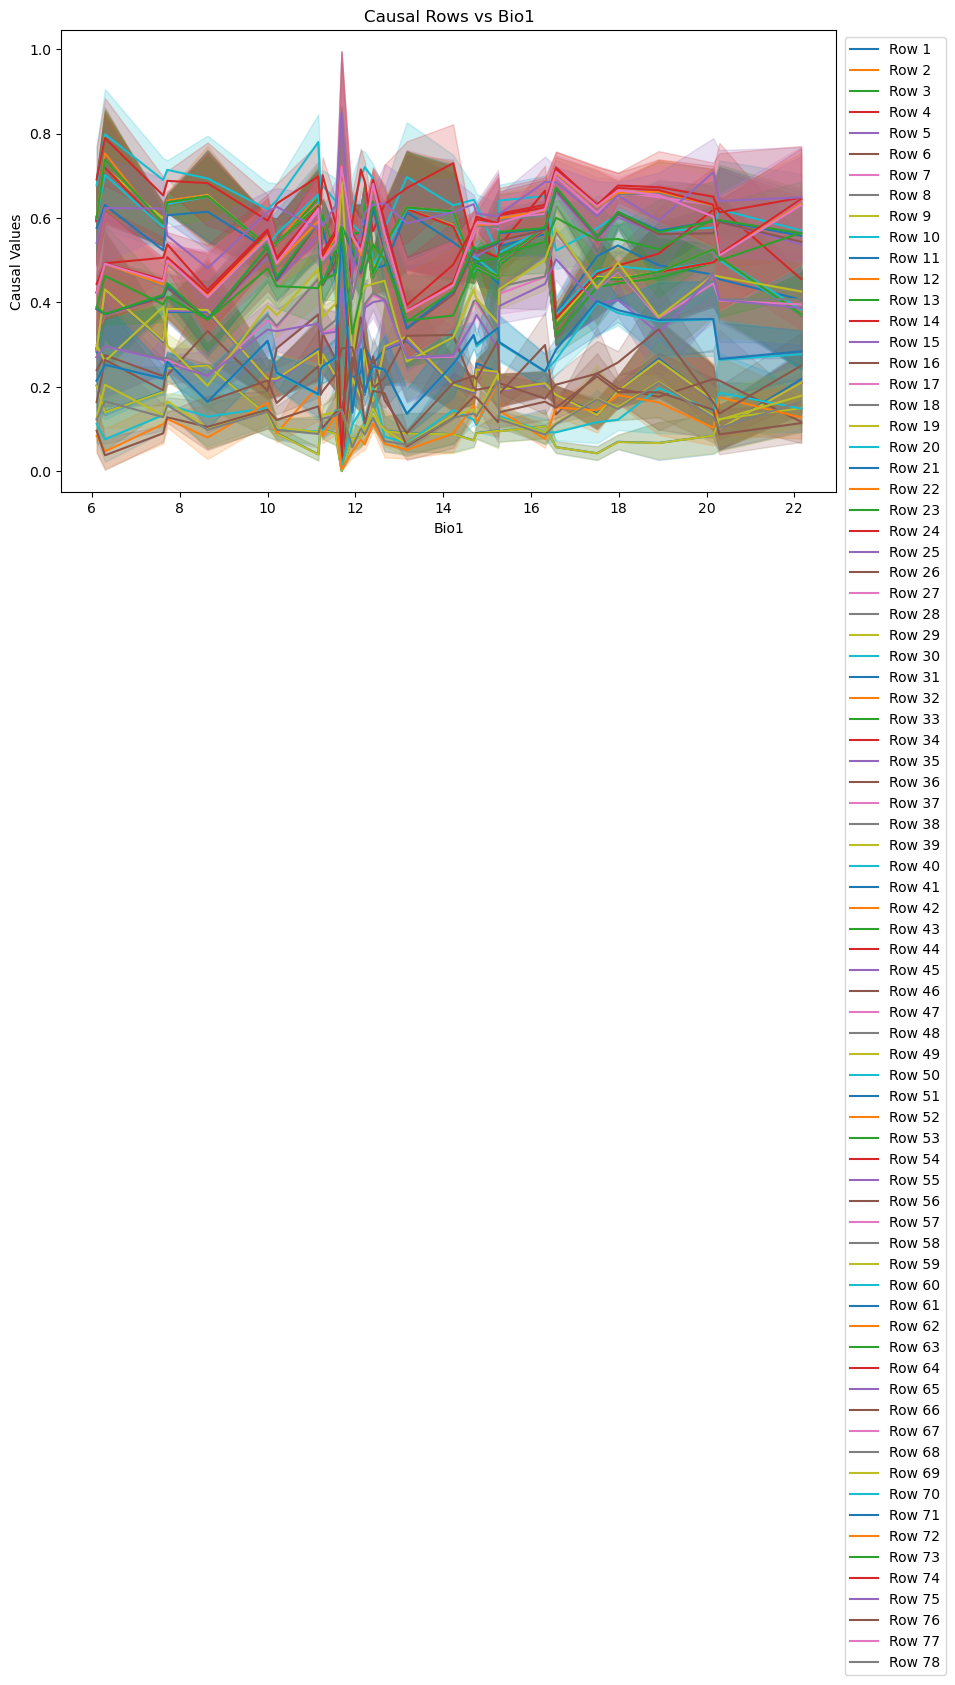

In [182]:
# Create the seaborn plot
plt.figure(figsize=(10, 6))

# Plot each row of causal as a line using seaborn
for i in range(causal_values.shape[1]):
    sns.lineplot(x=bio1, y=causal_values[i], label=f'Row {i+1}')

# Adding labels and title
plt.xlabel('Bio1')
plt.ylabel('Causal Values')
plt.title('Causal Rows vs Bio1')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

In [169]:
# Create the seaborn plot
plt.figure(figsize=(10, 6))

# Plot each row of causal as a line using seaborn
for i in range(causal.shape[1]):
    sns.lineplot(x=bio1, y=causal[i], label=f'Row {i+1}')

# Adding labels and title
plt.xlabel('Bio1')
plt.ylabel('Causal Values')
plt.title('Causal Rows vs Bio1')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

KeyError: 0

<Figure size 1000x600 with 0 Axes>

In [ ]:
causal = af_filt_blocks.merge(snps_dict_filt, right_on = 'id', left_on = '0')

causal.columns

causal = causal[causal['total_alleles05filter'].notna()].drop(['0', 'pos', 'chrom', 'maf05filter', 'total_alleles05filter', 'block'],axis=1).set_index('id')

samples = causal.columns

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_sites_era5_year_2018.csv')

sites_af = pd.Series(samples).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [162]:
import seaborn as sns


KeyError: 'x'

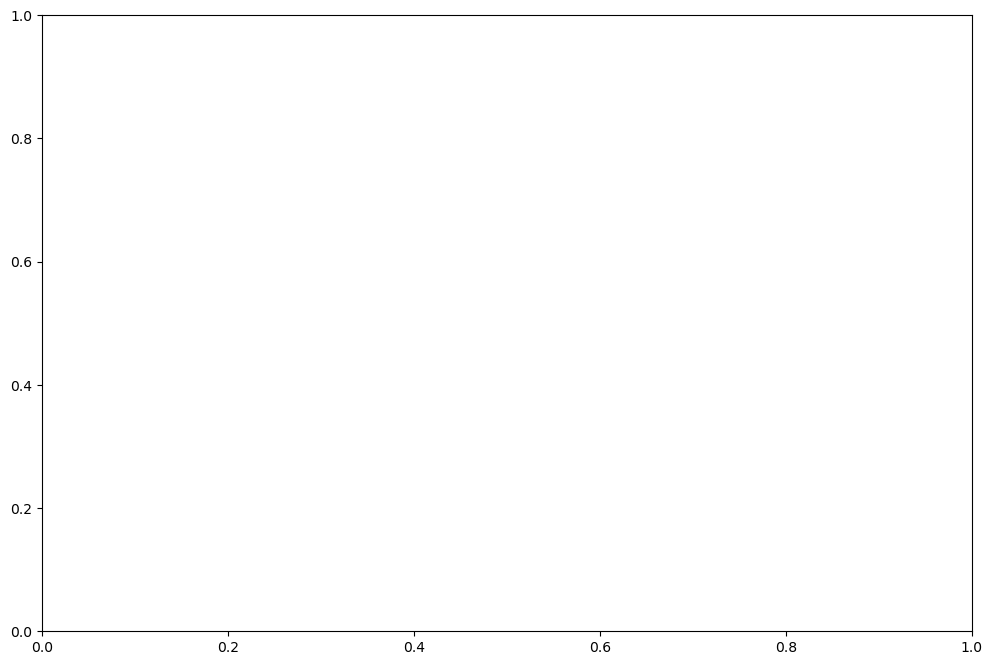

In [163]:
# Reset index to turn 'id' into a column
causal_reset = causal.reset_index()
causal_reset.rename(columns={'index': 'id'}, inplace=True)

# Melt the DataFrame to long format
causal_melted = causal_reset.melt(id_vars='id', var_name='bio1_index', value_name='value')

# Map the bio1 values
causal_melted['bio1'] = causal_melted['bio1_index'].map(bio1.to_dict())

# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='id', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [141]:
import matplotlib.pyplot as plt

In [148]:
import numpy as np


In [160]:
# Reset index to turn 'id' into a column
causal_reset = causal.reset_index()
causal_reset.rename(columns={'index': 'id'}, inplace=True)

# Melt the DataFrame to long format
causal_melted = causal_reset.melt(id_vars='id', var_name='bio1_index', value_name='value')
causal_melted['bio1'] = bio1[causal_melted['bio1_index']].values

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [159]:

# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='id', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [146]:
# Prepare the data for Seaborn
causal_melted = causal.reset_index().melt(id_vars='id', var_name='bio1_index', value_name='value')
causal_melted['bio1'] = bio1[causal_melted['bio1_index']].values

KeyError: "None of [Index(['1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1', '1_1_1',\n       '1_1_1', '1_1_1',\n       ...\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12', '60_1_12',\n       '60_1_12', '60_1_12', '60_1_12', '60_1_12'],\n      dtype='object', length=58110)] are in the [index]"

In [143]:


# Create a line plot for each row in the causal DataFrame using Seaborn
plt.figure(figsize=(12, 8))  # Adjust figure size as needed

sns.lineplot(data=causal_melted, x='bio1', y='value', hue='row', palette='tab20', alpha=0.7)

# Add labels and title
plt.xlabel('bio1')
plt.ylabel('Values from causal DataFrame')
plt.title('Line Plot of Each Row in Causal DataFrame Against bio1')
plt.legend(title='Row', bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend placement as needed
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

KeyError: 'index'

In [32]:
mask = snps_dict['block'].isin(genes).reset_index(drop=True)

In [57]:
new_mask = mask.loc[:899999]

In [35]:
ddf = dd.read_csv('../key_files/merged_hapFIRE_allele_frequency.txt', sep = '\t')

In [36]:
af = ddf.compute()


KeyboardInterrupt



In [ ]:
af = af.reset_index()

In [ ]:
af[mask]

In [ ]:



# Compute the number of NaNs per row
nan_count_per_row = ddf.isna().sum(axis=1)

# Filter the DataFrame
filtered_ddf = ddf[nan_count_per_row < 326]

f_fst = filtered_ddf.compute()

In [9]:
af = pd.read_csv('../key_files/allele_freq_maf05_mincount05_firstgensamples_windexsnpid.csv')


KeyboardInterrupt



In [ ]:
'../key_files/p0_average_seed_mix.csv'